In [1]:
# Standard Libraries
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Scikit-learn
from sklearn.metrics import confusion_matrix
# Keras
from keras import Sequential, Model
from keras.layers import (Input, Conv2D, Conv2DTranspose, concatenate, BatchNormalization, Activation, MaxPooling2D,AveragePooling2D, Dropout, Dense, Flatten)
from keras.callbacks import EarlyStopping

In [2]:
# Objects to hold pairs of images and masks
train_image_mask = {
    'images': [],
    'masks': []
}

test_image_mask = {
    'images': [],
    'masks': []
}

# Objects to hold pairs of images and labels
train_image_class = {
    'images': [],
    'labels': []
}

test_image_class = {
    'images': [],
    'labels': []
}

def load_image_mask(train_image_mask=None, test_image_mask=None, image_path=None, shape=256):
    """Generates image/mask pairs from the dataset.

    Args:
        train_image_mask (dict): Dictionary to store training images and masks.
        test_image_mask (dict): Dictionary to store testing images and masks.
        image_path (str): Path to the images and masks.
        shape (int): Size to resize images and masks.

    Returns:
        tuple: Updated dictionaries containing images and masks.
    """
    file_names = os.listdir(image_path)
    
    image_names = []
    mask_names = []
    partial_names = [fn.split(')')[0] for fn in file_names]
    
    partial_names = list(set(partial_names))
    
    for name in partial_names:
        image_names.append(name + ').png')
        mask_names.append(name + ')_mask.png')
        
    train_test_split_index = int(len(image_names) * 0.8)
    
    for i, image_name in enumerate(image_names):
        image = plt.imread(os.path.join(image_path, image_name))
        mask = plt.imread(os.path.join(image_path, mask_names[i]))
        
        image = cv2.resize(image, (shape, shape))
        mask = cv2.resize(mask, (shape, shape))
        
        if i < train_test_split_index:
            train_image_mask['images'].append(image)
            train_image_mask['masks'].append(mask)
        else:
            test_image_mask['images'].append(image)
            test_image_mask['masks'].append(mask)
        
    return train_image_mask, test_image_mask

def load_image_class(train_image_class=None, test_image_class=None, image_path=None, shape=256):
    """Generates image/label pairs from the dataset.

    Args:
        train_image_class (dict): Dictionary to store training images and labels.
        test_image_class (dict): Dictionary to store testing images and labels.
        image_path (str): Path to the images.
        shape (int): Size to resize images.

    Returns:
        tuple: Updated dictionaries containing images and labels.
    """
    file_names = os.listdir(image_path)
    image_class = os.path.basename(image_path)
    
    image_names = [fn.split(')')[0] + ').png' for fn in file_names]
    
    train_test_split_index = int(len(image_names) * 0.8)
    
    for i, image_name in enumerate(image_names):
        image = plt.imread(os.path.join(image_path, image_name))
        image = cv2.resize(image, (shape, shape))
        
        if i < train_test_split_index:
            train_image_class['images'].append(image)
            train_image_class['labels'].append(image_class)
        else:
            test_image_class['images'].append(image)
            test_image_class['labels'].append(image_class)
        
    return train_image_class, test_image_class

In [3]:
from pathlib import Path

base_dir = Path("Dataset_BUSI_with_GT")
categories = ['normal', 'benign', 'malignant']

for category in categories:
    image_dir = base_dir / category / 'images'
    mask_dir = base_dir / category / 'masks'
    
    print(f"Checking directories for category '{category}':")
    print(f"Images directory: {image_dir}")
    print(f"Masks directory: {mask_dir}")

    if image_dir.exists():
        print("Images directory exists.")
        print(list(image_dir.iterdir()))  # List files in the images directory
    else:
        print(f"Error: Images directory {image_dir} does not exist.")

    if mask_dir.exists():
        print("Masks directory exists.")
        print(list(mask_dir.iterdir()))  # List files in the masks directory
    else:
        print(f"Error: Masks directory {mask_dir} does not exist.")


Checking directories for category 'normal':
Images directory: Dataset_BUSI_with_GT\normal\images
Masks directory: Dataset_BUSI_with_GT\normal\masks
Error: Images directory Dataset_BUSI_with_GT\normal\images does not exist.
Error: Masks directory Dataset_BUSI_with_GT\normal\masks does not exist.
Checking directories for category 'benign':
Images directory: Dataset_BUSI_with_GT\benign\images
Masks directory: Dataset_BUSI_with_GT\benign\masks
Error: Images directory Dataset_BUSI_with_GT\benign\images does not exist.
Error: Masks directory Dataset_BUSI_with_GT\benign\masks does not exist.
Checking directories for category 'malignant':
Images directory: Dataset_BUSI_with_GT\malignant\images
Masks directory: Dataset_BUSI_with_GT\malignant\masks
Error: Images directory Dataset_BUSI_with_GT\malignant\images does not exist.
Error: Masks directory Dataset_BUSI_with_GT\malignant\masks does not exist.


In [4]:
folders = os.listdir(base_dir)
print(folders)

['benign', 'malignant', 'normal']


In [5]:
# Load Benign class images and masks
train_image_mask, test_image_mask = load_image_mask(
    train_image_mask=train_image_mask, 
    test_image_mask=test_image_mask, 
    image_path="Dataset_BUSI_with_GT/benign"
)

train_image_class, test_image_class = load_image_class(
    train_image_class=train_image_class, 
    test_image_class=test_image_class, 
    image_path="Dataset_BUSI_with_GT/benign"
)

# Load Malignant class images and masks
train_image_mask, test_image_mask = load_image_mask(
    train_image_mask=train_image_mask, 
    test_image_mask=test_image_mask, 
    image_path="Dataset_BUSI_with_GT/malignant"
)

train_image_class, test_image_class = load_image_class(
    train_image_class=train_image_class, 
    test_image_class=test_image_class, 
    image_path="Dataset_BUSI_with_GT/malignant"
)


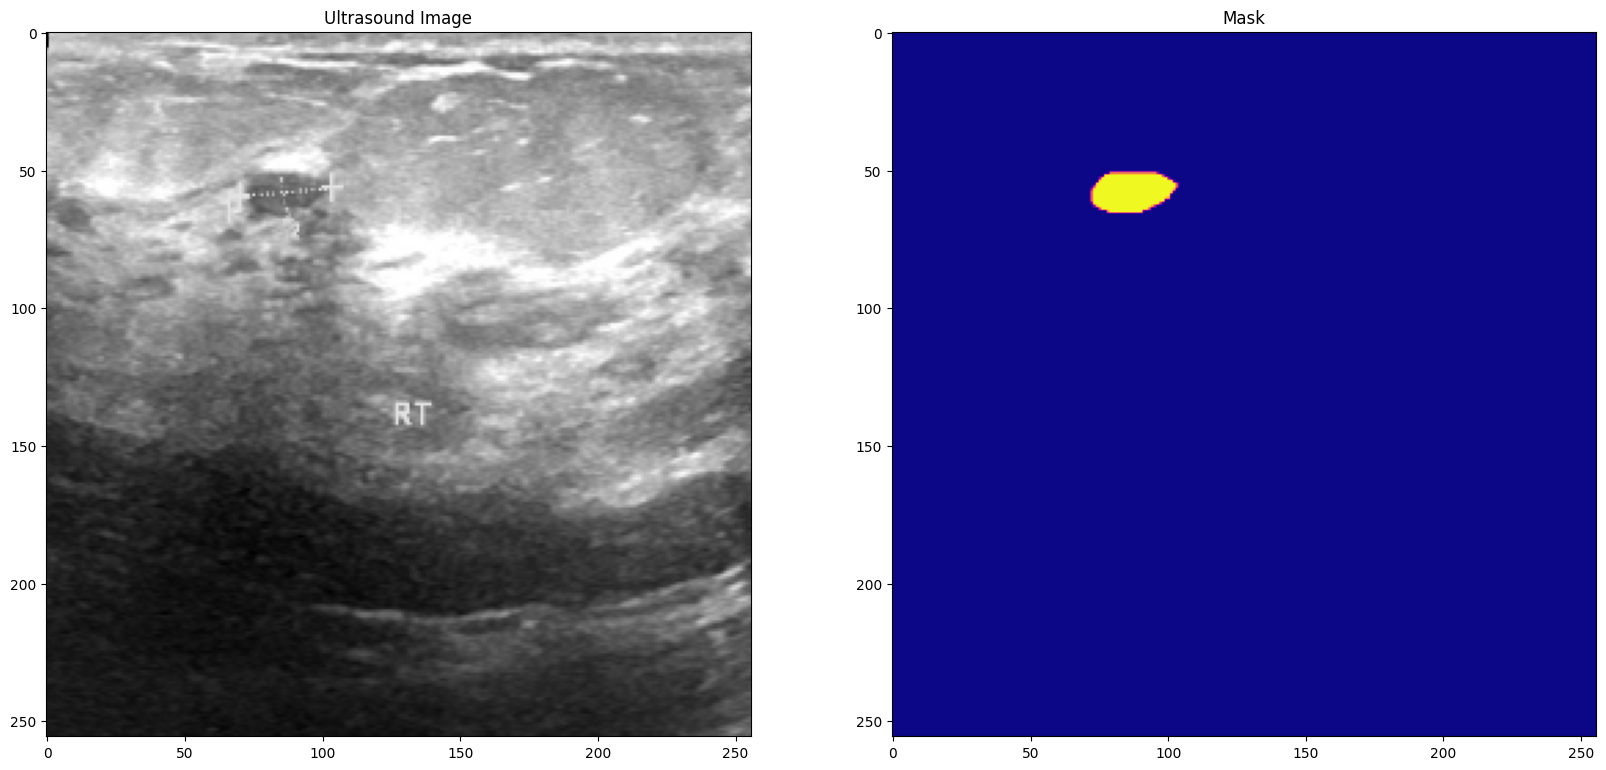

In [6]:
# Display one image/mask pair from the loaded dataset
plt.figure(figsize=(20, 20))

# Display the ultrasound image
plt.subplot(1, 2, 1)
plt.imshow(train_image_mask['images'][0])
plt.title('Ultrasound Image')

# Display the corresponding mask
plt.subplot(1, 2, 2)
plt.imshow(train_image_mask['masks'][0], cmap='plasma')
plt.title('Mask')

plt.show()

In [7]:
# Definition of one Convolution block of the U-Net architecture
def convolutionBlock(inputTensor, filterCount, kernelSize = 3):
    convolutionBlock = Conv2D(filters = filterCount, kernel_size = (kernelSize, kernelSize), kernel_initializer = 'he_normal', padding = 'same')(inputTensor)
    convolutionBlock = BatchNormalization()(convolutionBlock)
    convolutionBlock = Activation('relu')(convolutionBlock)
    
    convolutionBlock = Conv2D(filters = filterCount, kernel_size = (kernelSize, kernelSize), kernel_initializer = 'he_normal', padding = 'same')(convolutionBlock)
    convolutionBlock = BatchNormalization()(convolutionBlock)
    convolutionBlock = Activation('relu')(convolutionBlock)
    
    return convolutionBlock

# Definition of the entire U-Net architecture
def modelArchitecture(inputTensor, filterCount = 16, dropoutRate = 0.1):
    # Initialization of the encoder
    firstConvolution = convolutionBlock(inputTensor, filterCount)
    firstLayer = AveragePooling2D((2, 2))(firstConvolution)
    firstLayer = Dropout(dropoutRate)(firstLayer)
    
    secondConvolution = convolutionBlock(firstLayer, filterCount * 2)
    secondLayer = AveragePooling2D((2, 2))(secondConvolution)
    secondLayer = Dropout(dropoutRate)(secondLayer)
    
    thirdConvolution = convolutionBlock(secondLayer, filterCount * 4)
    thirdLayer = AveragePooling2D((2, 2))(thirdConvolution)
    thirdLayer = Dropout(dropoutRate)(thirdLayer)
    
    fourthConvolution = convolutionBlock(thirdLayer, filterCount * 8)
    fourthLayer = AveragePooling2D((2, 2))(fourthConvolution)
    fourthLayer = Dropout(dropoutRate)(fourthLayer)
    
    fifthConvolution = convolutionBlock(fourthLayer, filterCount * 16)
    
    # Initialization of the decoder
    firstDeconvolution = Conv2DTranspose(filterCount * 8, (3, 3), strides = (2, 2), padding = 'same')(fifthConvolution)
    sixthLayer = concatenate([firstDeconvolution, fourthConvolution])
    sixthLayer = Dropout(dropoutRate)(sixthLayer)
    sixthConvolution = convolutionBlock(sixthLayer, filterCount * 8)
    
    secondDeconvolution = Conv2DTranspose(filterCount * 4, (3, 3), strides = (2, 2), padding = 'same')(sixthConvolution)
    seventhLayer = concatenate([secondDeconvolution, thirdConvolution])
    seventhLayer = Dropout(dropoutRate)(seventhLayer)
    seventhConvolution = convolutionBlock(seventhLayer, filterCount * 4)
    
    thirdDeconvolution = Conv2DTranspose(filterCount * 2, (3, 3), strides = (2, 2), padding = 'same')(seventhConvolution)
    eighthLayer = concatenate([thirdDeconvolution, secondConvolution])
    eighthLayer = Dropout(dropoutRate)(eighthLayer)
    eighthConvolution = convolutionBlock(eighthLayer, filterCount * 2)
    
    fourthDeconvolution = Conv2DTranspose(filterCount, (3, 3), strides = (2, 2), padding = 'same')(eighthConvolution)
    ninthLayer = concatenate([fourthDeconvolution, firstConvolution])
    ninthLayer = Dropout(dropoutRate)(ninthLayer)
    ninthConvolution = convolutionBlock(ninthLayer, filterCount)
    
    outputLayer = Conv2D(1, (1, 1), activation = 'sigmoid')(ninthConvolution)
    segmentationModel = Model(inputs = [inputTensor], outputs = [outputLayer])
    
    return segmentationModel

In [8]:
# Initialization of the segmentation model
inputs = Input((256, 256, 3))

segmentationModel = modelArchitecture(inputs, dropoutRate = 0.1)
segmentationModel.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
segmentationModel.summary()




Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 16)         448       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 16)         64        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 256, 256, 16)         0         ['batch_normalization[0

In [9]:
history = segmentationModel.fit(
    np.array(train_image_mask['images']), 
    np.array(train_image_mask['masks']),
    epochs=75,
    validation_data=(
        np.array(test_image_mask['images']), 
        np.array(test_image_mask['masks'])
    ),
    callbacks=[
        EarlyStopping(
            patience=15, 
            monitor='val_loss', 
            mode='min', 
            restore_best_weights=True, 
            verbose=1
        )
    ]
)


Epoch 1/75


17/17 [==============================] - 100s 5s/step - loss: 0.5731 - accuracy: 0.7844 - val_loss: 5.6232 - val_accuracy: 0.5035
Epoch 2/75
17/17 [==============================] - 95s 6s/step - loss: 0.3901 - accuracy: 0.9040 - val_loss: 12.5132 - val_accuracy: 0.1119
Epoch 3/75
17/17 [==============================] - 92s 5s/step - loss: 0.3035 - accuracy: 0.9239 - val_loss: 11.0615 - val_accuracy: 0.1378
Epoch 4/75
17/17 [==============================] - 105s 6s/step - loss: 0.2680 - accuracy: 0.9280 - val_loss: 9.8856 - val_accuracy: 0.1720
Epoch 5/75
17/17 [==============================] - 100s 6s/step - loss: 0.2434 - accuracy: 0.9321 - val_loss: 3.9272 - val_accuracy: 0.4764
Epoch 6/75
17/17 [==============================] - 100s 6s/step - loss: 0.2359 - accuracy: 0.9293 - val_loss: 3.9264 - val_accuracy: 0.5149
Epoch 7/75
17/17 [==============================] - 101s 6s/step - loss: 0.2181 - accuracy: 0.9346 - val_loss: 1.2666 - val_accuracy: 0.7571
Epoch 8/75


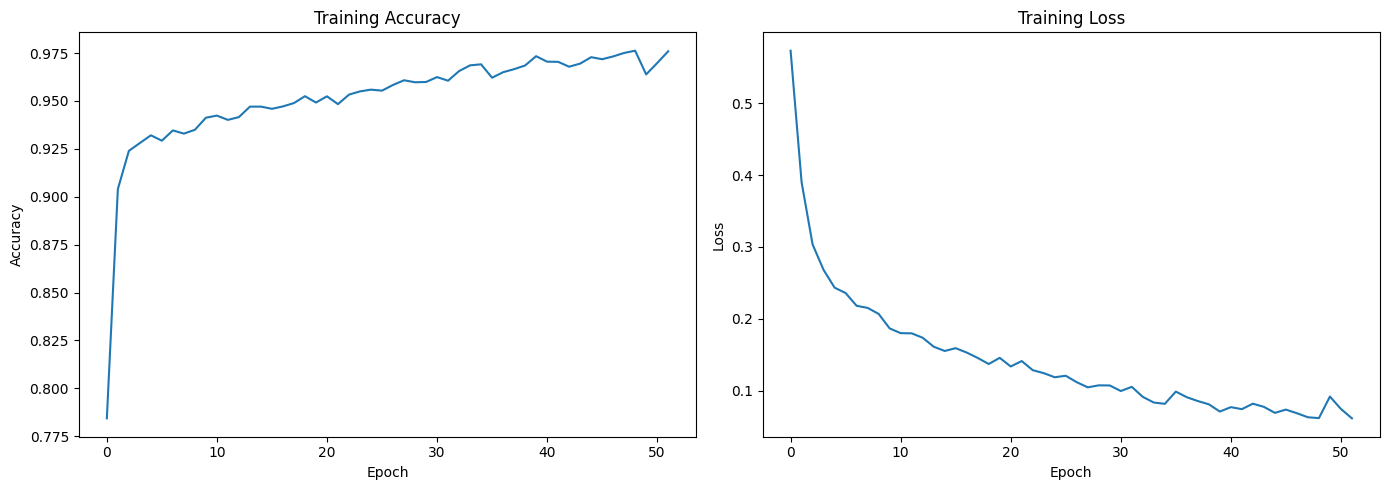

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = history.history['accuracy']
loss = history.history['loss']
epochs = range(len(accuracy))

# Convert accuracy and loss to a DataFrame for easier plotting with Seaborn
history_df = pd.DataFrame({
    'Epoch': epochs,
    'Accuracy': accuracy,
    'Loss': loss
})

# Create subplots to place the plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training accuracy using Seaborn
sns.lineplot(data=history_df, x='Epoch', y='Accuracy', ax=axes[0])
axes[0].set_title('Training Accuracy')

# Plot training loss using Seaborn
sns.lineplot(data=history_df, x='Epoch', y='Loss', ax=axes[1])
axes[1].set_title('Training Loss')

# Display the plots
plt.tight_layout()
plt.show()


In [11]:
testImages = test_image_mask['images']
testMasks = test_image_mask['masks']

predictions = segmentationModel.predict(np.array(testImages))
print(predictions.shape)

5/5 [==============================] - 5s 796ms/step
(130, 256, 256, 1)


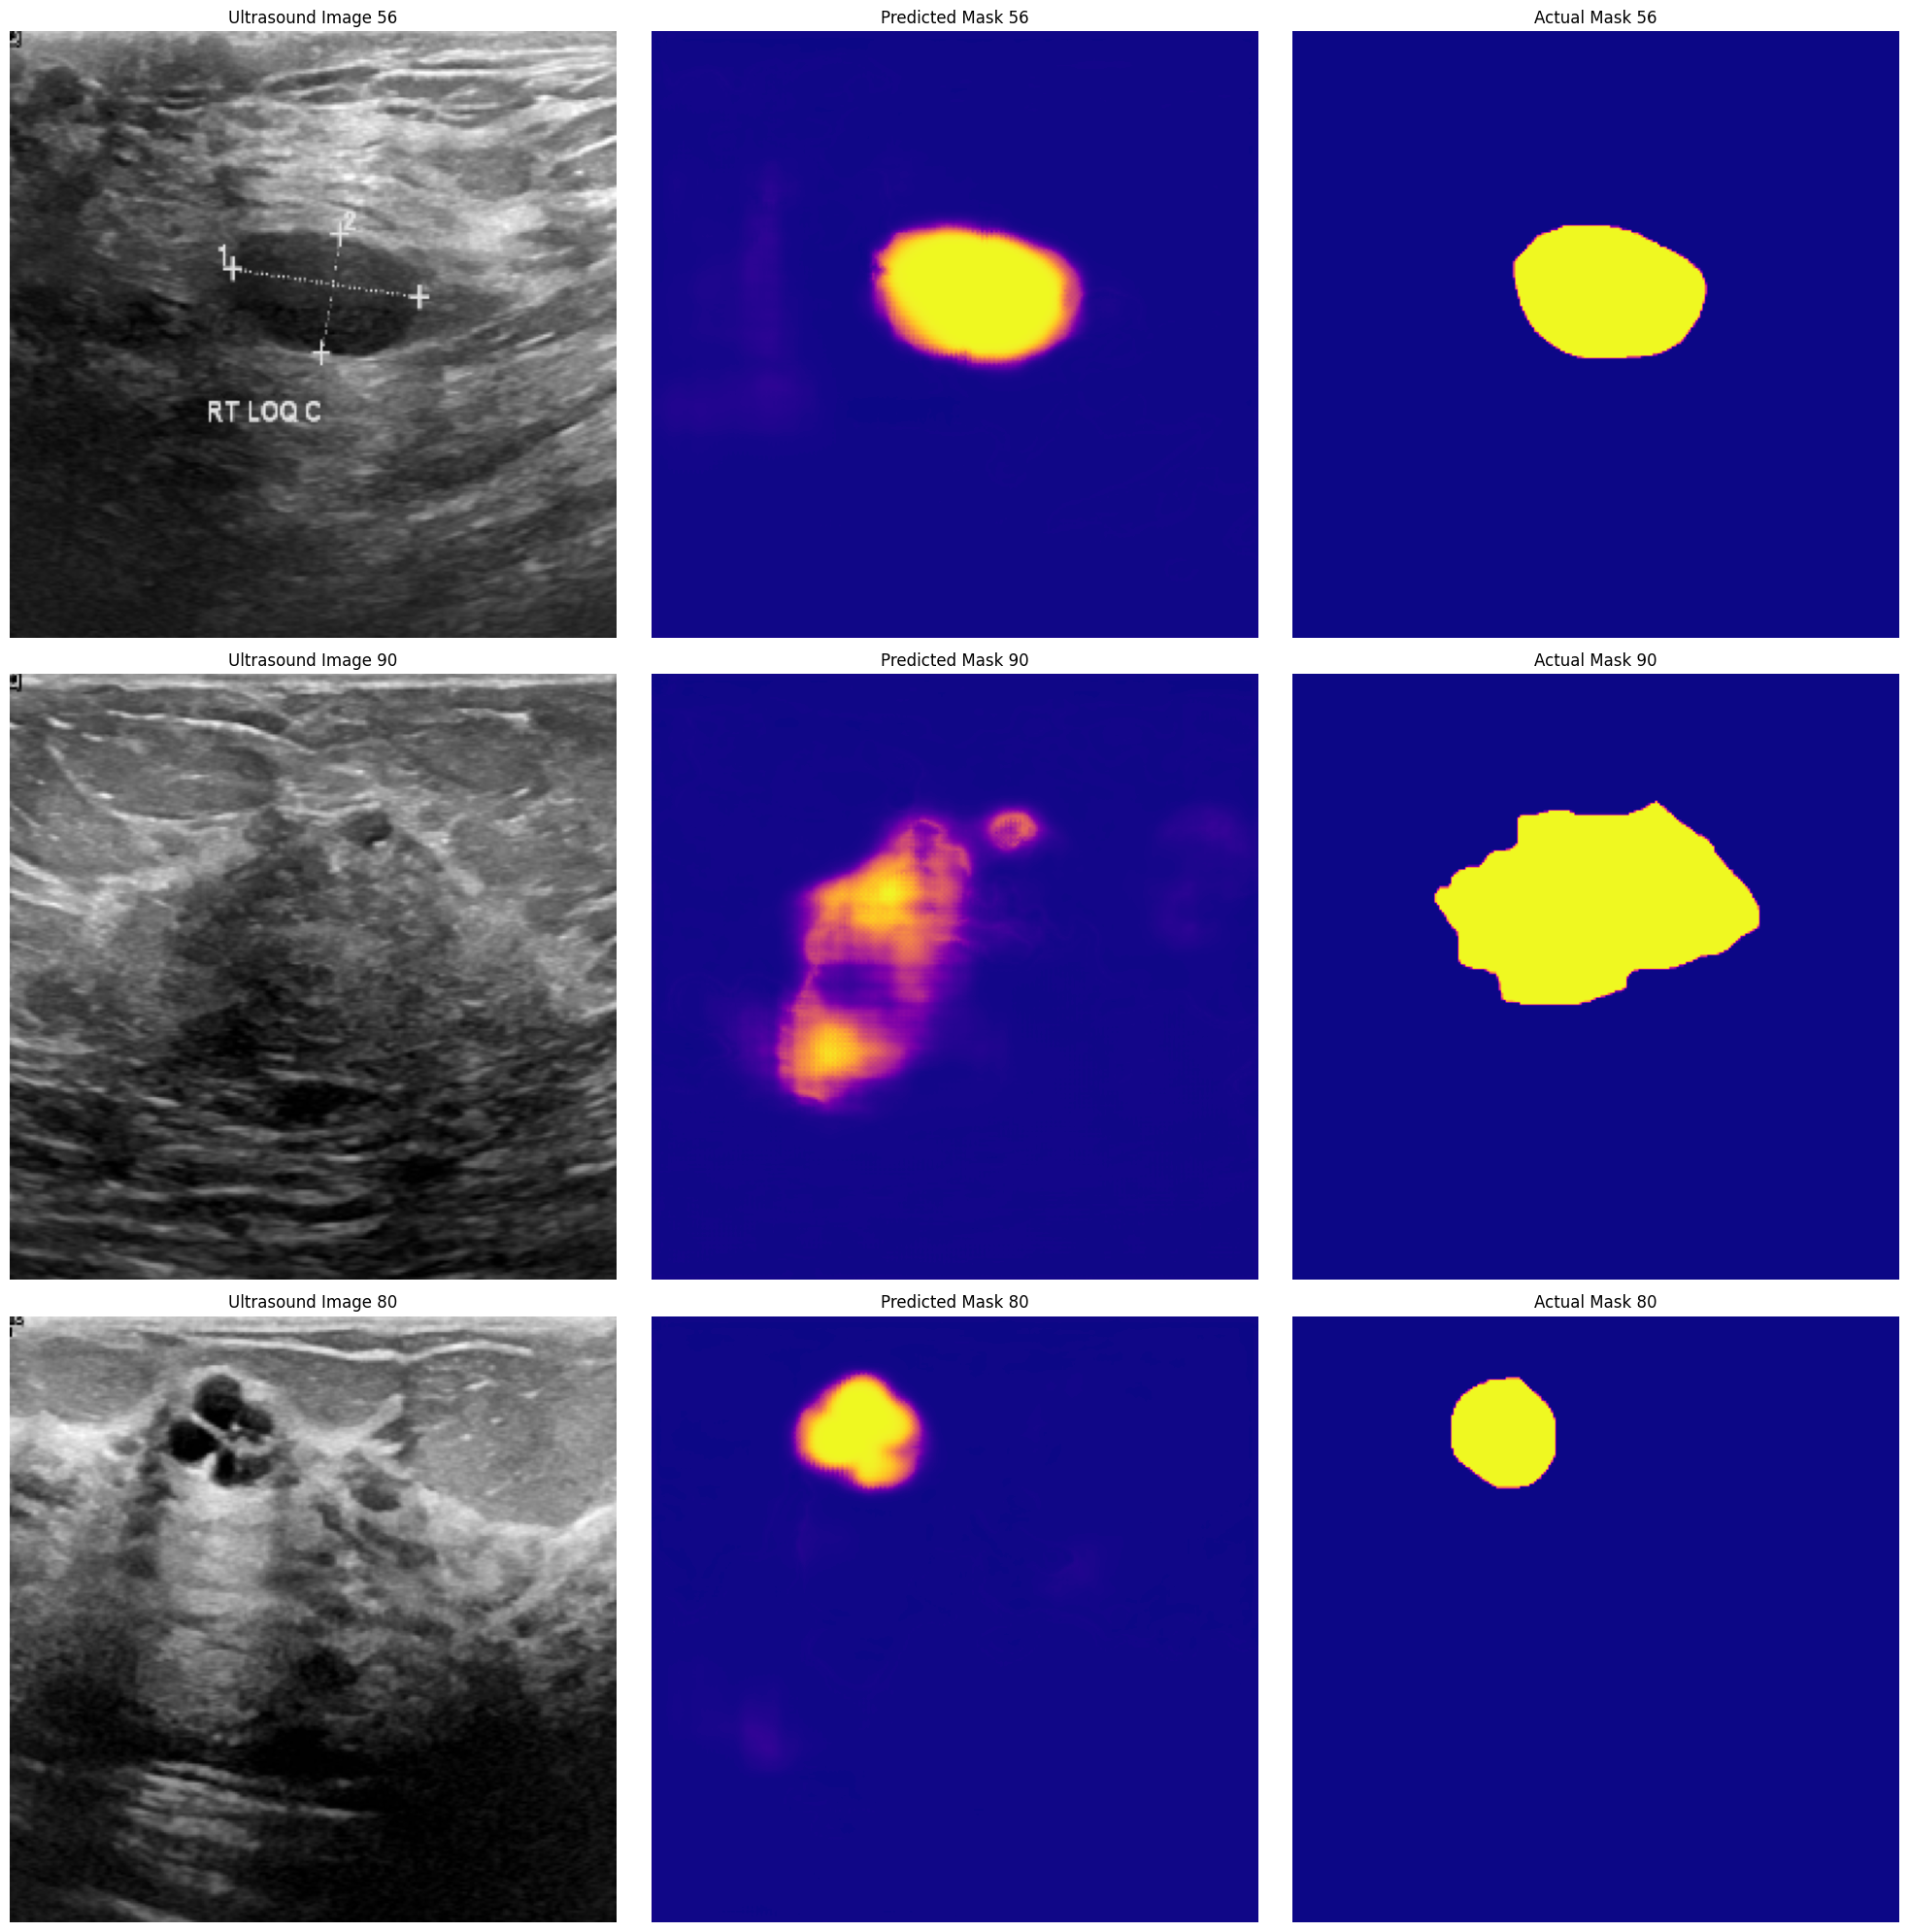

In [12]:
import matplotlib.pyplot as plt

# Define the indices for the images you want to plot
indices = [56, 90, 80]  # Modify these indices as needed

# Initialize the figure with a 3x3 grid
plt.figure(figsize=(20, 20))

# Loop over the indices and create subplots
for i, idx in enumerate(indices):
    # Determine the row and column for each image
    row = i // 3  # Row index (0 for the first row, 1 for the second row, etc.)
    col = i % 3   # Column index (0 for the first column, 1 for the second column, etc.)
    
    # Plot Ultrasound Image
    plt.subplot(3, 3, 3*i + 1)
    plt.imshow(testImages[idx])
    plt.title(f'Ultrasound Image {idx}')
    plt.axis('off')
    
    # Plot Predicted Mask
    plt.subplot(3, 3, 3*i + 2)
    plt.imshow(predictions[idx], cmap='plasma')
    plt.title(f'Predicted Mask {idx}')
    plt.axis('off')
    
    # Plot Actual Mask
    plt.subplot(3, 3, 3*i + 3)
    plt.imshow(testMasks[idx], cmap='plasma')
    plt.title(f'Actual Mask {idx}')
    plt.axis('off')

# Adjust layout and show the figure
plt.tight_layout()
plt.show()

In [13]:
segmentationModel.save('Final Final Breast Cancer Segmentation.h5')

c:\Users\Hosopa\anaconda3\envs\grad_ai\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Classifaction Model

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = 224
BATCH_SIZE = 16

# ----------------- تحميل البيانات -----------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Dataset_BUSI_with_GT",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Dataset_BUSI_with_GT",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 1578 files belonging to 3 classes.
Using 1263 files for training.
Found 1578 files belonging to 3 classes.
Using 315 files for validation.
Classes: ['benign', 'malignant', 'normal']


In [15]:
# ----------------- Data Augmentation -----------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ----------------- بناء الموديل -----------------
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True  # Fine-tune top layers
for layer in base_model.layers[:-50]:
    layer.trainable = False  # Freeze bottom layers

model_cls = models.Sequential([
    data_augmentation,                 # augment data
    layers.Rescaling(1./255),          # normalize
    base_model,                        # pretrained backbone
    layers.GlobalAveragePooling2D(),   # flatten features
    layers.Dropout(0.5),               # prevent overfitting
    layers.Dense(3, activation='softmax')  # output 3 classes
])

# ----------------- Compile -----------------
model_cls.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# ----------------- Callbacks -----------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'bes__model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

# ----------------- تدريب الموديل -----------------
history = model_cls.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
79/79 [==============================] - 38s 373ms/step - loss: 1.1693 - accuracy: 0.4743 - val_loss: 1.0442 - val_accuracy: 0.6317
Epoch 2/50
79/79 [==============================] - 28s 355ms/step - loss: 0.7604 - accuracy: 0.6722 - val_loss: 0.8539 - val_accuracy: 0.7016
Epoch 3/50
79/79 [==============================] - 28s 349ms/step - loss: 0.6344 - accuracy: 0.7411 - val_loss: 0.7505 - val_accuracy: 0.6825
Epoch 4/50
79/79 [==============================] - 27s 344ms/step - loss: 0.5684 - accuracy: 0.7546 - val_loss: 0.6546 - val_accuracy: 0.7175
Epoch 5/50
79/79 [==============================] - 28s 349ms/step - loss: 0.5461 - accuracy: 0.7490 - val_loss: 0.5954 - val_accuracy: 0.7556
Epoch 6/50
79/79 [==============================] - 27s 337ms/step - loss: 0.5115 - accuracy: 0.7838 - val_loss: 0.5466 - val_accuracy: 0.7587
Epoch 7/50
79/79 [==============================] - 26s 329ms/step - loss: 0.4646 - accuracy: 0.8021 - val_loss: 0.5165 - val_accuracy: 0.7746

In [17]:

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,              
    restore_best_weights=True
)


history_continue = model_cls.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,          # هيكمل 20 epoch كمان (يعني لحد 70)
    callbacks=[early_stop]
)


Epoch 1/50
79/79 [==============================] - 28s 352ms/step - loss: 0.1678 - accuracy: 0.9382 - val_loss: 0.2394 - val_accuracy: 0.9016
Epoch 2/50
79/79 [==============================] - 27s 341ms/step - loss: 0.1450 - accuracy: 0.9509 - val_loss: 0.2356 - val_accuracy: 0.8984
Epoch 3/50
79/79 [==============================] - 27s 343ms/step - loss: 0.1519 - accuracy: 0.9422 - val_loss: 0.2339 - val_accuracy: 0.8921
Epoch 4/50
79/79 [==============================] - 27s 342ms/step - loss: 0.1373 - accuracy: 0.9525 - val_loss: 0.2385 - val_accuracy: 0.8952
Epoch 5/50
79/79 [==============================] - 27s 340ms/step - loss: 0.1455 - accuracy: 0.9454 - val_loss: 0.2367 - val_accuracy: 0.9048
Epoch 6/50
79/79 [==============================] - 27s 343ms/step - loss: 0.1346 - accuracy: 0.9509 - val_loss: 0.2333 - val_accuracy: 0.8984
Epoch 7/50
79/79 [==============================] - 27s 342ms/step - loss: 0.1359 - accuracy: 0.9501 - val_loss: 0.2367 - val_accuracy: 0.9016

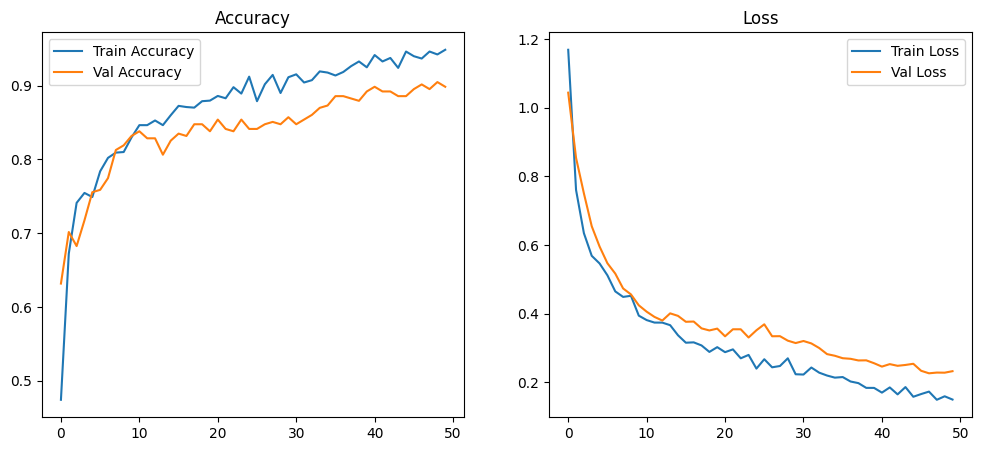

In [18]:
# ----------------- رسم الدقة والخسارة -----------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()


1/1 [==============================] - 0s 137ms/step
Classification Report:

              precision    recall  f1-score   support

      benign       0.95      0.92      0.94       168
   malignant       0.88      0.94      0.91        82
      normal       0.91      0.89      0.90        65

    accuracy                           0.92       315
   macro avg       0.91      0.92      0.91       315
weighted avg       0.92      0.92      0.92       315



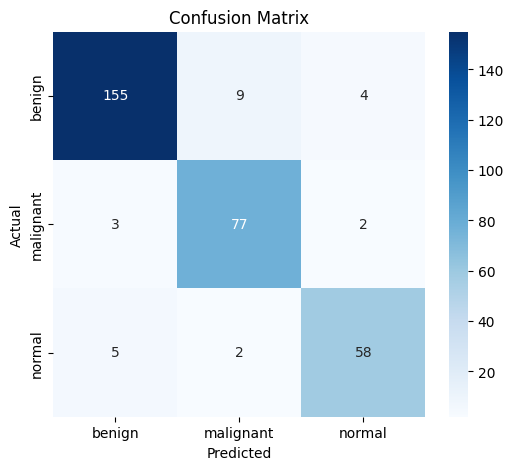

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ----------------- جمع التوقعات -----------------
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model_cls.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ----------------- Classification Report -----------------
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# ----------------- Confusion Matrix -----------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [20]:

img_path = "E:\Graduation Project\Breast Cancer\Dataset_BUSI_with_GT\benign\benign (1)_mask.png"

In [21]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

IMG_SIZE = 224

def predict_image(img_path, model, class_names):
    # تحميل الصورة
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # (1,224,224,3)

    # توقع
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # عرض الصورة والنتيجة
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.show()

    print("Predicted Class:", predicted_class)
    print("Confidence: {:.2f}%".format(confidence))


# مثال تشغيل
predict_image("test_image.jpg", model_cls, class_names)


FileNotFoundError: [Errno 2] No such file or directory: 'test_image.jpg'

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

IMG_SIZE = 224

def predict_image(img_path):
    # نتأكد إن الملف موجود
    if not os.path.exists(img_path):
        print(" الصورة مش موجودة في المسار ده")
        return
    
    # تحميل الصورة
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # لو الموديل مفيهوش Rescaling جوه
    img_array = img_array / 255.0

    # التوقع
    predictions = model_cls.predict(img_array)
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    # عرض النتيجة
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.show()

    print("Predicted Class:", predicted_class)
    print("Confidence: {:.2f}%".format(confidence))


1/1 [==============================] - 0s 99ms/step


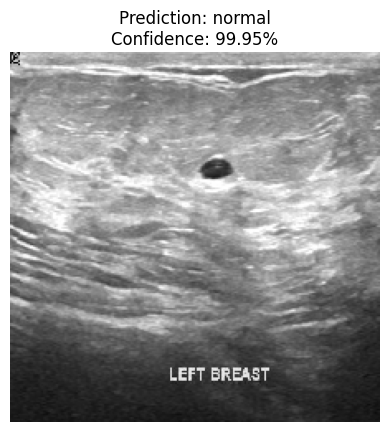

Predicted Class: normal
Confidence: 99.95%


In [ ]:
predict_image("Dataset_BUSI_with_GT/benign/benign (1).png")
